<a href="https://colab.research.google.com/github/KadeejaHibaPT/AML_lab/blob/main/AMLlab_exp1B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Number of flips: 10
Heads: 2
Tails: 8

Bernoulli Log-Likelihood:
log L(theta) = 2 log(theta) + 8 log(1-theta)

Posterior Distribution:
Beta(7, 13)

MAP Estimate:
Numerical MAP = 0.3337
Closed-form MAP = 0.3333


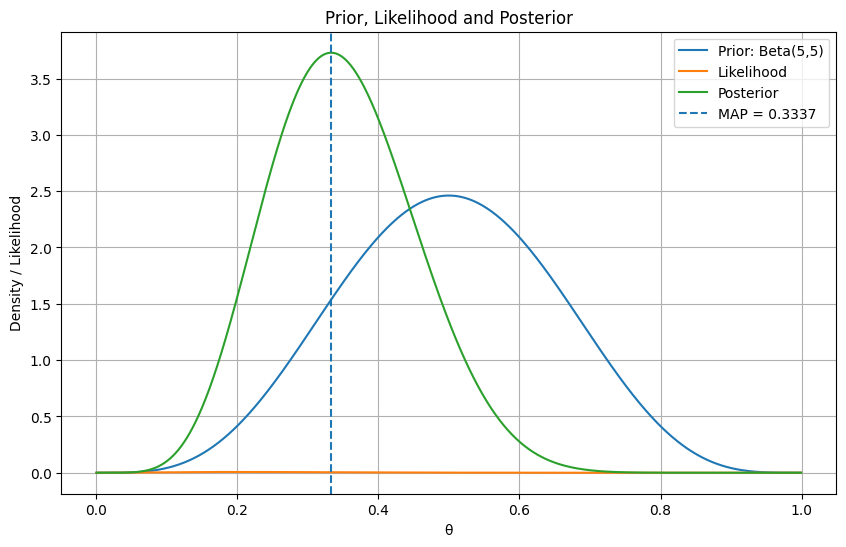

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import beta

results = ['H', 'T', 'T', 'T', 'H', 'T', 'T', 'T', 'T', 'T']

heads = results.count('H')
tails = results.count('T')
n = len(results)

print("Number of flips:", n)
print("Heads:", heads)
print("Tails:", tails)

theta = np.linspace(0.001, 0.999, 1000)

likelihood = theta**heads * (1 - theta)**tails

alpha = 5
beta_prior = 5

prior = (theta**(alpha - 1) * (1 - theta)**(beta_prior - 1)) / beta(alpha, beta_prior)

posterior_unnormalized = likelihood * prior

normalization = np.trapezoid(posterior_unnormalized, theta)
posterior = posterior_unnormalized / normalization

map_index = np.argmax(posterior)
map_theta = theta[map_index]

posterior_alpha = alpha + heads
posterior_beta = beta_prior + tails

map_closed = (posterior_alpha - 1) / (posterior_alpha + posterior_beta - 2)

print("\nBernoulli Log-Likelihood:")
print("log L(theta) = 2 log(theta) + 8 log(1-theta)")

print("\nPosterior Distribution:")
print(f"Beta({posterior_alpha}, {posterior_beta})")

print("\nMAP Estimate:")
print("Numerical MAP =", round(map_theta, 4))
print("Closed-form MAP =", round(map_closed, 4))

plt.figure(figsize=(10, 6))

plt.plot(theta, prior, label='Prior: Beta(5,5)')
plt.plot(theta, likelihood, label='Likelihood')
plt.plot(theta, posterior, label='Posterior')

plt.axvline(map_theta, linestyle='--', label=f'MAP = {map_theta:.4f}')

plt.xlabel('θ')
plt.ylabel('Density / Likelihood')
plt.title('Prior, Likelihood and Posterior')
plt.legend()
plt.grid()

plt.show()